# Model Prediction Analysis

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ieeg.auth import Session
from itertools import chain
import scipy as sc
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
from functools import reduce

# Stat imports
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML Imports
from sklearn.metrics import cohen_kappa_score, f1_score, matthews_corrcoef
import statsmodels.formula.api as smf

from matplotlib.markers import MarkerStyle

# OS imports
from os.path import join as ospj
from os.path import exists as ospe
from tqdm import tqdm
from utils import *
import sys
sys.path.append('/users/wojemann/iEEG_processing')
import os

In [2]:
plt.rcParams['image.cmap'] = 'magma'

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2

plt.rcParams['xtick.major.size'] = 5  # Change to your desired major tick size
plt.rcParams['ytick.major.size'] = 5  # Change to your desired major tick size
plt.rcParams['xtick.minor.size'] = 3   # Change to your desired minor tick size
plt.rcParams['ytick.minor.size'] = 3   # Change to your desired minor tick size

plt.rcParams['xtick.major.width'] = 2  # Change to your desired major tick width
plt.rcParams['ytick.major.width'] = 2  # Change to your desired major tick width
plt.rcParams['xtick.minor.width'] = 1  # Change to your desired minor tick width
plt.rcParams['ytick.minor.width'] = 1  # Change to your desired minor tick width
pal = sns.color_palette('Set2')[:2][::-1] + ['grey']

In [3]:
usr,passpath,datapath,prodatapath,metapath,figpath,patient_table,rid_hup,pt_list = load_config(ospj('/mnt/sauce/littlab/users/wojemann/stim-seizures/code','config.json'))

## Workspace Preparation

In [4]:
COMBINER = 75

In [5]:
sz_metadata = pd.read_csv(ospj(metapath,'stim_seizure_information_BIDS.csv'))

In [6]:
# Loading seizure level metadata
mdl_str = 'LSTM'
data_str = "optimized_predicted_channels_LSTM_tuned_thresholds_v4_sz-mean_pt-mean_smooth-med.pkl"
sz_annots = pd.read_pickle(ospj(prodatapath,data_str))
sz_annots = sz_annots[sz_annots.Patient != 'CHOP015']
# sz_annots = pd.read_pickle(ospj(prodatapath,f"optimized_predicted_channels_{mdl_str}_tuned_thresholds_v3.pkl"))
# print((test.threshold == sz_annots.threshold).sum()/len(test))
sz_annots.columns = [col if col != 'Patient' else 'patient' for col in sz_annots.columns]
# sz_annots = sz_annots[sz_annots.Patient.apply(lambda x: x[:3] != 'CHO')]

shared_channels = sz_annots.groupby('patient')['all_channels'].transform(lambda x: [list(set.intersection(*map(set, x)))] * len(x))
sz_annots['all_channels'] = shared_channels
sz_annots.sort_values('approximate_onset',inplace=True)

## Seizure Annotation Preparation

### Merging annotations and seizure metadata

In [7]:
seizures_df = pd.read_csv(ospj(metapath,"stim_seizure_information - LF_seizure_annotation.csv"))
seizures_df.dropna(axis=0,how='all',inplace=True)
seizures_df.rename(columns=dict(Patient='patient',IEEGname='iEEG_ID'),inplace=True)
seizures_df['approximate_onset'].fillna(seizures_df['UEO'],inplace=True)
seizures_df['approximate_onset'].fillna(seizures_df['EEC'],inplace=True)
seizures_df['approximate_onset'].fillna(seizures_df['Other_onset_description'],inplace=True)
# drop HF stim induced seizures
seizures_df = seizures_df[seizures_df.stim != 2]
seizures_df.sort_values('approximate_onset',inplace=True)

sz_annots = pd.merge_asof(sz_annots,
            seizures_df[['approximate_onset','patient',"iEEG_ID","typical","stim_channels"]],
            on='approximate_onset',by=['patient','iEEG_ID'],
            tolerance = 240,
            direction='nearest')

sz_annots.sort_values(['patient','iEEG_ID','approximate_onset'],inplace=True)

### Mapping channels to regions and adding stim channels

In [8]:
STIMFLAG=True
pt_groups = sz_annots.groupby('patient')

for pt, group in pt_groups:
    region_path = get_rpath(prodatapath, pt)
    if ospe(region_path):
        electrode_regions = pd.read_pickle(region_path)

    pt_stim_chs = set()

    for idx, row in group.iterrows():
        if STIMFLAG and isinstance(row.stim_channels, str):
            stim_chs = clean_labels(row.stim_channels.split('-'), '')
            pt_stim_chs.update(stim_chs)

        if STIMFLAG and row.stim == 1:
            sz_annots.at[idx, 'sz_chs'] = np.concatenate([row.sz_chs, stim_chs])
            sz_annots.at[idx, 'sz_times'] = np.concatenate([row.sz_times, [0, 0]])

    # Compute shared all_channels once
    all_annotated_channels = set.union(*[set(chs) for chs in group['all_channels']])
    all_annotated_channels.update(pt_stim_chs)
    final_all_channels = np.array(sorted(all_annotated_channels))

    # Assign the same array to every row for this patient
    for idx in group.index:
        sz_annots.at[idx, 'all_channels'] = final_all_channels


In [9]:
for idx, row in sz_annots.iterrows():
    pt = row.patient
    region_path = get_rpath(prodatapath, pt)
    if ospe(region_path):
        electrode_regions = pd.read_pickle(region_path)

        # Updated all_rs
        all_rs = electrode_regions[electrode_regions.name.isin(row['all_channels'])]['label']
        all_rs = [r for r in all_rs.unique() if ((r != 'EmptyLabel') and ('white' not in r.lower()) and ('wm' not in r.lower()))]
        sz_annots.at[idx, 'all_rs'] = np.array(all_rs)

        # Updated sz_rs
        labels = []
        for ch in row.sz_chs:
            match = electrode_regions[electrode_regions.name == ch]['label']
            labels.append(match.values[0] if not match.empty else 'UnknownRegion')
        sz_annots.at[idx, 'sz_rs'] = np.array(labels)

        for col in ['ueo_chs_strict', 'ueo_chs_loose', 'sec_chs_strict', 'sec_chs_loose']:
            chs = row[col]
            sz_annots.at[idx, col + '_mask'] = np.array([ch in chs for ch in row['all_channels']])

            electrode_locals = electrode_regions[electrode_regions.name.isin(chs)]['label']
            electrode_locals = [r for r in electrode_locals if ((r != 'EmptyLabel') and ('white' not in r.lower()) and ('wm' not in r.lower()))]

            all_rs = np.atleast_1d(sz_annots.loc[idx, 'all_rs'])
            sz_annots.at[idx, col.replace('chs', 'rs')] = np.array(electrode_locals)
            sz_annots.at[idx, col.replace('chs', 'rs') + '_mask'] = np.array([l in electrode_locals for l in all_rs])

sz_annots.dropna(axis=0,subset='stim',inplace=True)
sz_annots.sort_values(['approximate_onset'],inplace=True)
sz_annots_rs = sz_annots.dropna(axis=0,subset=['all_rs']).copy()

In [10]:
# sz_annots.to_pickle('example_sz_annots.pkl')

### Seizure Metadata

Excluded patients:
HUP274, HUP282, CHOP036, CHOP047 had no spontaneous seizures
CHOP015, CHOP032, CHOP038, and CHOP046 had technical errors preventing the upload of spontaneous seizures


In [11]:
print(sz_annots.patient.nunique())
print(sz_annots[sz_annots.patient.apply(lambda x: 'HUP' in x)].patient.nunique())
print(len(sz_annots[sz_annots.patient.apply(lambda x: 'HUP' in x)]))
print(len(sz_annots[sz_annots.patient.apply(lambda x: 'CHOP' in x)]))
print(sz_annots[sz_annots.stim==1].approximate_onset.nunique())
print(sz_annots[sz_annots.patient.apply(lambda x: 'HUP' in x) & (sz_annots.stim==1)].approximate_onset.nunique())
print(sz_annots[sz_annots.patient.apply(lambda x: 'CHOP' in x) & (sz_annots.stim==1)].approximate_onset.nunique())

30
19
334
107
43
23
20


In [12]:
np.sort(sz_annots.patient.unique())

array(['CHOP005', 'CHOP010', 'CHOP024', 'CHOP026', 'CHOP028', 'CHOP035',
       'CHOP037', 'CHOP041', 'CHOP044', 'CHOP045', 'CHOP049', 'HUP224',
       'HUP225', 'HUP229', 'HUP230', 'HUP235', 'HUP238', 'HUP246',
       'HUP247', 'HUP249', 'HUP250', 'HUP253', 'HUP257', 'HUP261',
       'HUP263', 'HUP266', 'HUP267', 'HUP273', 'HUP275', 'HUP288'],
      dtype=object)

## Stim-Spontaneous Electrographic Similarity

### Seizure -- channel

In [13]:
def calculate_seizure_similarity(annots,first_annot = 'ueo_consensus', second_annot = 'ueo_consensus',paired=True):
    annot_list = ["kappa","F1","MCC","patient","spont","typical"]
    annot_dict = {key:[] for key in annot_list}
    skip_pt = []
    for pt,group in annots.groupby("patient"):
        if (sum(group.stim == 0) < 2) and paired:
            skip_pt.append(pt)
            continue
        elif len(group) < 2:
            skip_pt.append(pt)
            continue
        # Iterate through each seizure
        for i in range(len(group)):
            group.reset_index(drop=True,inplace=True)
            ch_mask = group.loc[i,first_annot].reshape(-1)
            for j in range(i+1,len(group)):
                if (group.loc[i,'stim'] == 1)  and (group.loc[j,'stim'] == 1): # skip both stim
                    continue
                ch_mask2 = group.loc[j,second_annot].reshape(-1)
                annot_dict["kappa"].append(cohen_kappa_score(ch_mask,ch_mask2))
                annot_dict["F1"].append(f1_score(ch_mask,ch_mask2))
                annot_dict["MCC"].append(matthews_corrcoef(ch_mask,ch_mask2))
                annot_dict["spont"].append(not ((group.loc[i,'stim'] == 1)  or (group.loc[j,'stim'] == 1)))
                # want to append a boolean that will tell me if one sz is stim and one sz is typical
                annot_dict["typical"].append(((group.loc[i,'typical'] == 1)  
                                                        or (group.loc[j,'typical'] == 1)))
                annot_dict["patient"].append(pt)
    annot_df = pd.DataFrame(annot_dict)
    print(f"Skipped {skip_pt} due to insufficient spontaneous seizures")
    return annot_df

    
def plot_seizure_similarity(dat,agreement='MCC',palette=['red','blue','purple'],annot_type='',
                            sz_level=True, binary = False, typical = None, combiner = 75,
                            annot_stats=True):
    if typical is not None:
        all_groups = []
        for _, group in dat.groupby(['patient']):
            stims = group.loc[(group.spont==False) & (group.typical == typical),:]

            if len(stims) == 0:
                continue
            
            all_groups.append(pd.concat([stims,group.loc[group.spont,:]],axis=0))

        dat = pd.concat(all_groups, axis=0)


    def percentile(x,combiner=combiner):
        return np.percentile(x,combiner,method='nearest')
        # return np.mean(x)


    # Define the aggregation functions
    numeric_cols = dat.select_dtypes(include='number').columns
    non_numeric_cols = dat.select_dtypes(exclude='number').columns.difference(['patient', 'spont'])
    
    if (agreement == 'Rank'):
        dat['Rank'] = dat['Rank'].fillna(0)
        # dat = dat[~dat.isna().any(axis=1)]

    pt_data = dat.groupby(['patient', 'spont']).agg(
        {col: percentile for col in numeric_cols} |
        {col: 'max' for col in non_numeric_cols}
    ).reset_index()

    # pt_data = data.groupby(["patient","spont"])[["kappa","F1"]].apply(agg_funcs).reset_index()
    fig,ax = plt.subplots(figsize=(4,5))
    if sz_level:
        model = smf.mixedlm(f"{agreement} ~ C(spont)", dat, groups="patient")
        result = model.fit()
        print(result.summary())
        print(result.pvalues)
        plot_data = dat
        # plt.title(f"Seizure-Level Seizure{annot_type} Similarity")

    else:
        plot_data = pt_data
        _,p = sc.stats.wilcoxon(pt_data[~pt_data.spont].sort_values('patient')[agreement],pt_data[pt_data.spont].sort_values('patient')[agreement])
        if binary:
            cont = pd.crosstab(pt_data.spont,pt_data[agreement])
            res = sc.stats.chi2_contingency(cont)
            p = res.pvalue
            print(res)
            fig1,ax1 = plt.subplots()
            sns.heatmap(cont,annot=True,robust=True,
                        xticklabels=True,yticklabels=True,
                        cmap=sns.light_palette("seagreen", as_cmap=True),
                        ax=ax1,
                        cbar=False)
            ax1.set_yticks([0.5,1.5],["Stim-Spont","Spont-Spont"])
            ax1.set_xlabel("Region Agreement?")
            ax1.set_ylabel("")
            fig1.savefig(ospj(figpath,"one_onset_region_boxes.pdf"))
        d = cohens_d(pt_data[~pt_data.spont][agreement],pt_data[pt_data.spont][agreement])
        # print(f"Paired t-test - p: {p}, d: {d}")
        # ax.set_title(f"Patient-Level Seizure{annot_type} Similarity")

    ax = sns.pointplot(data=plot_data,x="spont",y=agreement,
                errorbar=None,
                markers="_",
                linestyles="none",
                palette=palette[:2],
                estimator=np.median,
                linewidth=4,
                markersize=45,
                ax=ax)
    # plt.setp(ax.lines, linewidth=20)
    sns.swarmplot(data=plot_data,x="spont",y=agreement,
                alpha=.7,
                palette = palette[:2],
                ax=ax
                # hue='patient'
                )
    if annot_stats:
        annotator = Annotator(ax,[(True,False)],data=plot_data,x='spont',y=agreement)
        annotator.configure(test='Wilcoxon',
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
        annotator.apply_and_annotate()

    plt.ylim([-0.25,1.15])
    sns.despine()
    ax.set_xticks([0,1],["Stim Induced-\nSpontaneous","Spontaneous-\nSpontaneous"])
    ax.set_xlabel('')
    # ax.set_ylabel(f"Electrographic Similarity ({agreement})")
    ax.set_ylabel('Onset Similarity ($\phi$)')
    x_spont = plot_data[plot_data.spont][agreement]
    x_stim = plot_data[~plot_data.spont][agreement]

    print(f"Spontaneous: N = {len(x_spont)} {x_spont.median():.2f} [{np.percentile(x_spont,25,method='nearest'):.2f}, {np.percentile(x_spont,75,method='nearest'):.2f}]")
    print(f"Stim: N = {len(x_stim)} {x_stim.median():.2f} [{np.percentile(x_stim,25,method='nearest'):.2f}, {np.percentile(x_stim,75,method='nearest'):.2f}]")


    return fig,ax

In [14]:
ch_similarity_df = calculate_seizure_similarity(sz_annots,first_annot='ueo_chs_strict_mask',second_annot='ueo_chs_strict_mask',paired=True)

Skipped ['HUP229', 'HUP246'] due to insufficient spontaneous seizures


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:6.082e-03 Stat=4.200e+01
Spontaneous: N = 28 0.56 [0.31, 0.73]
Stim: N = 28 0.23 [0.00, 0.50]


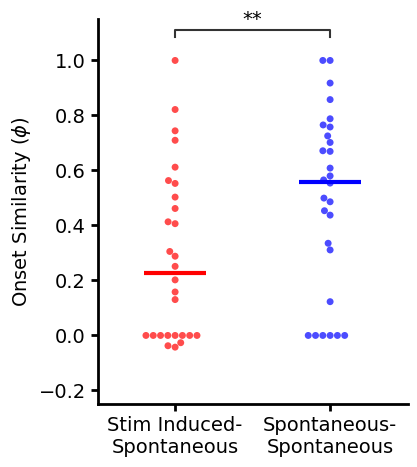

In [15]:
fig,_ = plot_seizure_similarity(ch_similarity_df,agreement='MCC',sz_level=False,typical=None,annot_stats=True,combiner=COMBINER)
fig.savefig(ospj(figpath,"ch_sz_similarity.pdf"),bbox_inches='tight')

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:1.172e-02 Stat=0.000e+00
Spontaneous: N = 12 0.70 [0.12, 0.77]
Stim: N = 12 0.00 [0.00, 0.13]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:2.343e-01 Stat=4.500e+01
Spontaneous: N = 19 0.49 [0.00, 0.61]
Stim: N = 19 0.31 [0.00, 0.56]


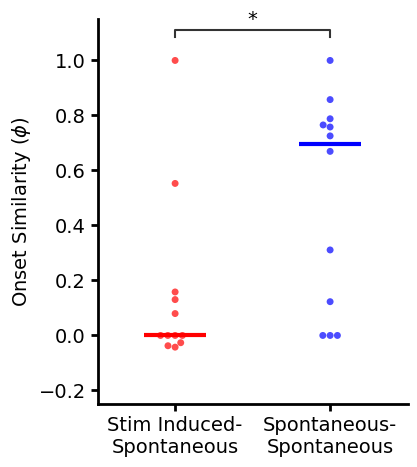

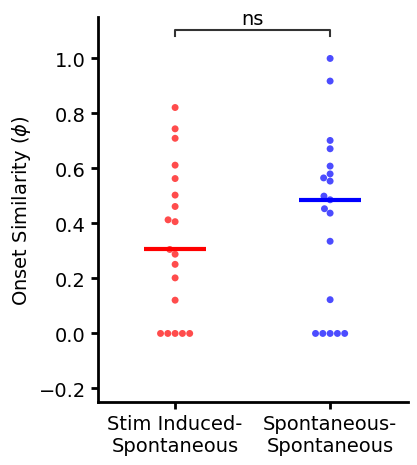

In [16]:
fig,_ = plot_seizure_similarity(ch_similarity_df,agreement='MCC',sz_level=False,typical=False,combiner=COMBINER,annot_stats=True)
fig.savefig(ospj(figpath,"channel_sz_similarity_atypical.pdf"),bbox_inches='tight')
fig,_ = plot_seizure_similarity(ch_similarity_df,agreement='MCC',sz_level=False,typical=True,combiner=COMBINER,annot_stats=True)
fig.savefig(ospj(figpath,"channel_sz_similarity_typical.pdf"),bbox_inches='tight')

In [17]:
all_stim_annots = []
all_spont_annots = []
annot_type = 'ueo'
con_type = 'loose'
example_pt = 'HUP257'
group = sz_annots[sz_annots.patient == example_pt]
group.sort_values(ascending=False,by='stim',inplace=True)
kappa_mat = np.zeros((len(group),len(group))); kappa_mat[:] = np.nan
group.reset_index(drop=True,inplace=True)
for i in range(len(group)):
    ch_mask = group.loc[i,f'{annot_type}_chs_{con_type}_mask']
    if group.loc[i,'stim'] == 1:
        print(f"{i} is stim")
    for j in range(i+1,len(group)):
        ch_mask2 = group.loc[j,f'{annot_type}_chs_{con_type}_mask']
        kappa_mat[i,j] = cohen_kappa_score(ch_mask,ch_mask2)

0 is stim


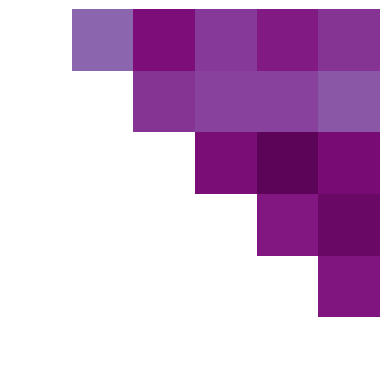

In [18]:
fig,ax = plt.subplots()
plt.imshow(kappa_mat,cmap = 'BuPu')
plt.clim(0,1)
plt.xticks([])
plt.yticks([])
for spine in ax.spines.values():
            spine.set_visible(False)
plt.savefig(ospj(figpath,f'ueo_heatmap_pt-{example_pt}.pdf'),bbox_inches='tight')

### Seizure -- region

In [19]:
r_similarity_df = calculate_seizure_similarity(sz_annots_rs,first_annot='ueo_rs_strict_mask',second_annot='ueo_rs_strict_mask')

Skipped ['HUP229', 'HUP246'] due to insufficient spontaneous seizures


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:6.205e-03 Stat=2.700e+01
Spontaneous: N = 28 0.67 [0.45, 0.79]
Stim: N = 28 0.29 [0.00, 0.64]


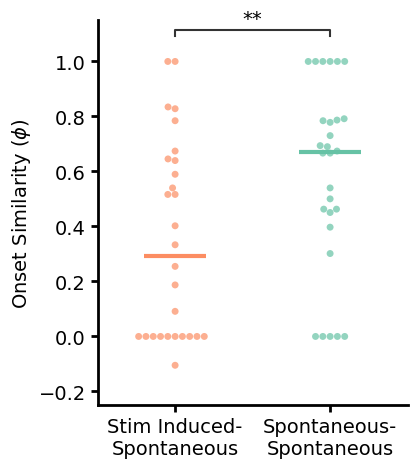

In [20]:
fig,_ = plot_seizure_similarity(r_similarity_df,agreement='MCC',palette=pal,sz_level=False,typical=None,combiner=COMBINER)
fig.savefig(ospj(figpath,"region_sz_similarity.pdf"),bbox_inches='tight')

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:1.172e-02 Stat=0.000e+00
Spontaneous: N = 12 0.68 [0.40, 0.79]
Stim: N = 12 0.00 [0.00, 0.09]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:3.967e-01 Stat=3.900e+01
Spontaneous: N = 19 0.54 [0.30, 0.78]
Stim: N = 19 0.52 [0.00, 0.78]


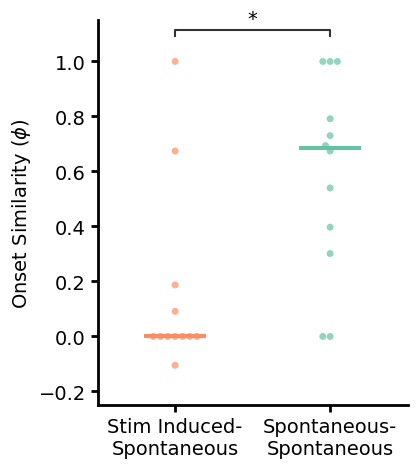

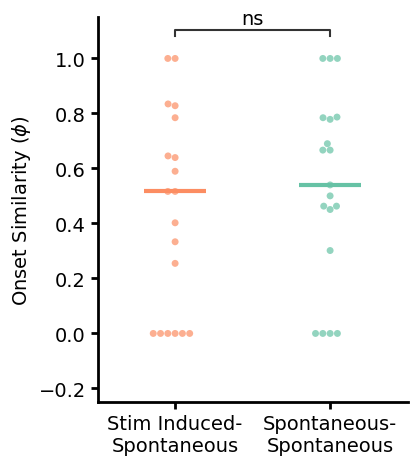

In [21]:
fig,_ = plot_seizure_similarity(r_similarity_df,agreement='MCC',palette=pal,sz_level=False,typical=False,combiner=COMBINER)
fig.savefig(ospj(figpath,"region_sz_similarity_atypical.pdf"),bbox_inches='tight')
fig,_ = plot_seizure_similarity(r_similarity_df,agreement='MCC',palette=pal,sz_level=False,typical=True,combiner=COMBINER)
fig.savefig(ospj(figpath,"region_sz_similarity_typical.pdf"),bbox_inches='tight')

### Spread rank

In [18]:
def calculate_spread_similarity(annots, first_annot='sz_chs', second_annot='sz_chs',
                                 sources='all_channels', spread_thresh=30, paired=True):
    annot_list = ["MCC", "Rank", "patient", "spont", "typical"]
    annot_dict = {key: [] for key in annot_list}
    skip_pt = []

    for pt, group in annots.groupby("patient"):
        if (sum(group.stim == 0) < 2 and paired) or (len(group) < 2):
            skip_pt.append(pt)
            continue

        group = group.reset_index(drop=True)

        for i in range(len(group)):
            sz_i = group.loc[i]
            if len(sz_i['sz_times']) == 0:
                continue

            # Create mask for channels/regions recruited before spread_thresh
            ch_time_mask = np.array(sz_i['sz_times']) < spread_thresh
            ch_mask = np.isin(sz_i[sources], np.array(sz_i[first_annot])[ch_time_mask])

            # Use groupby one-liner to get minimum time per unit
            onset_dict = pd.DataFrame({
                "unit": sz_i[first_annot],
                "time": sz_i['sz_times']
            }).groupby("unit")["time"].min().to_dict()

            max_latency = max(onset_dict.values()) + 1
            all_latencies = np.array([onset_dict.get(ch, max_latency) for ch in sz_i[sources]])

            for j in range(i + 1, len(group)):
                sz_j = group.loc[j]
                if sz_i['stim'] == 1 and sz_j['stim'] == 1:
                    continue
                if len(sz_j['sz_times']) == 0:
                    continue

                ch_time_mask2 = np.array(sz_j['sz_times']) < spread_thresh
                ch_mask2 = np.isin(sz_j[sources], np.array(sz_j[second_annot])[ch_time_mask2])

                onset_dict2 = pd.DataFrame({
                    "unit": sz_j[second_annot],
                    "time": sz_j['sz_times']
                }).groupby("unit")["time"].min().to_dict()

                max_latency2 = max(onset_dict2.values()) + 1
                all_latencies2 = np.array([onset_dict2.get(ch, max_latency2) for ch in sz_j[sources]])

                annot_dict["MCC"].append(matthews_corrcoef(ch_mask, ch_mask2))
                annot_dict["Rank"].append(sc.stats.spearmanr(all_latencies, all_latencies2).statistic)
                annot_dict["spont"].append(not (sz_i['stim'] == 1 or sz_j['stim'] == 1))
                annot_dict["typical"].append(sz_i['typical'] == 1 or sz_j['typical'] == 1)
                annot_dict["patient"].append(pt)

    annot_df = pd.DataFrame(annot_dict)
    print(f"Skipped {skip_pt} due to insufficient spontaneous seizures")
    return annot_df

In [27]:
ch_spread_df = calculate_spread_similarity(sz_annots,first_annot = 'sz_chs', second_annot = 'sz_chs', sources = 'all_channels', spread_thresh = 10, paired=True)

Skipped ['HUP229', 'HUP246'] due to insufficient spontaneous seizures


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:1.259e-06 Stat=1.600e+01
Spontaneous: N = 28 0.78 [0.66, 0.83]
Stim: N = 28 0.55 [0.44, 0.66]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:4.883e-04 Stat=0.000e+00
Spontaneous: N = 12 0.79 [0.66, 0.84]
Stim: N = 12 0.43 [0.35, 0.53]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxo

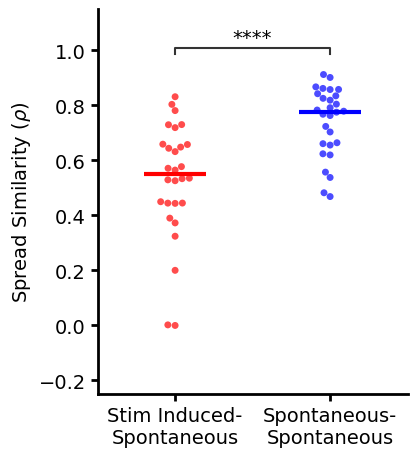

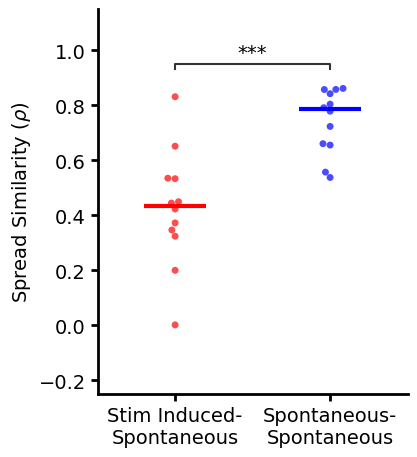

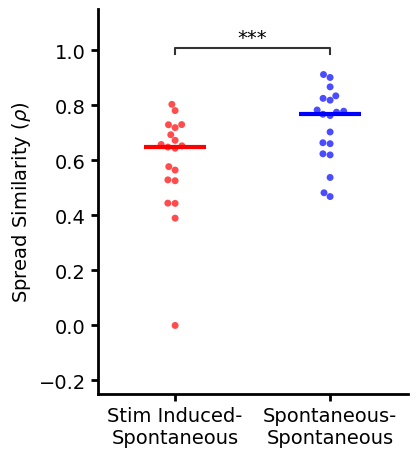

In [28]:
fig,ax = plot_seizure_similarity(ch_spread_df,agreement='Rank',sz_level=False,typical=None,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"channel_sz_spread.pdf"),bbox_inches='tight')
fig,ax = plot_seizure_similarity(ch_spread_df,agreement='Rank',sz_level=False,typical=False,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"channel_sz_spread_atypical.pdf"),bbox_inches='tight')
fig,ax = plot_seizure_similarity(ch_spread_df,agreement='Rank',sz_level=False,typical=True,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"channel_sz_spread_typical.pdf"),bbox_inches='tight')

In [26]:
r_spread_df = calculate_spread_similarity(sz_annots_rs,first_annot = 'sz_rs', second_annot = 'sz_rs', sources = 'all_rs', spread_thresh = 10, paired=True)

Skipped ['HUP229', 'HUP246'] due to insufficient spontaneous seizures


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:1.353e-04 Stat=4.600e+01
Spontaneous: N = 28 0.78 [0.60, 0.86]
Stim: N = 28 0.55 [0.39, 0.68]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxon test (paired samples), P_val:1.465e-03 Stat=2.000e+00
Spontaneous: N = 12 0.66 [0.51, 0.83]
Stim: N = 12 0.43 [0.36, 0.49]
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Wilcoxo

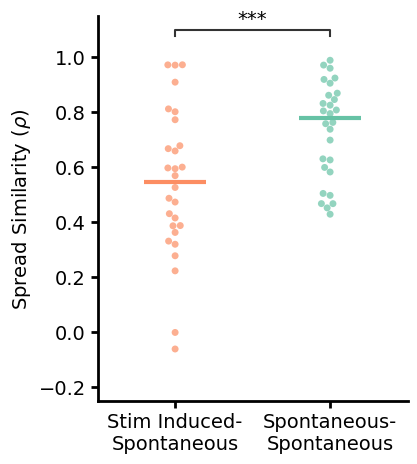

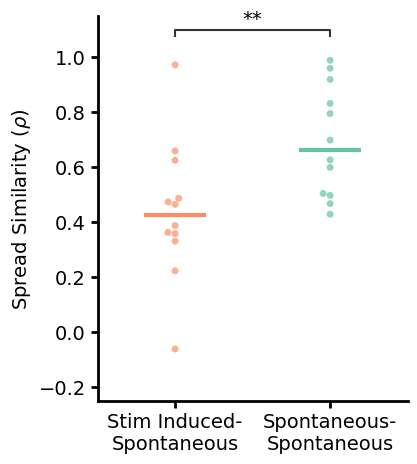

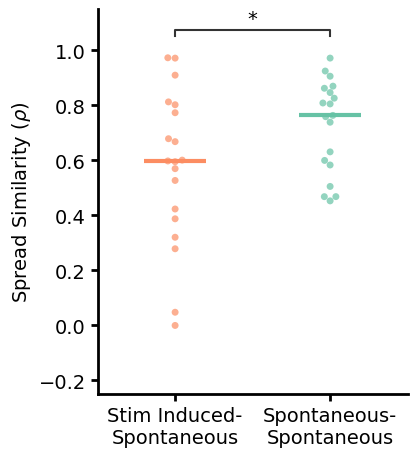

In [29]:
fig,ax = plot_seizure_similarity(r_spread_df,agreement='Rank',palette=pal,sz_level=False,typical=None,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"region_sz_spread.pdf"),bbox_inches='tight')
fig,ax = plot_seizure_similarity(r_spread_df,agreement='Rank',palette=pal,sz_level=False,typical=False,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"region_sz_spread_atypical.pdf"),bbox_inches='tight')
fig,ax = plot_seizure_similarity(r_spread_df,agreement='Rank',palette=pal,sz_level=False,typical=True,combiner=COMBINER)
ax.set_ylabel('Spread Similarity ($\\rho$)')
fig.savefig(ospj(figpath,"region_sz_spread_typical.pdf"),bbox_inches='tight')

## Channels recruited

In [10]:
def total_sz_recruitment(row):
    szing_rs_mask = np.isin(row.all_channels,row.sz_chs)
    return sum(szing_rs_mask)/len(szing_rs_mask)*100
    
def total_onset_recruitment(row):
    szing_chs_mask = row.ueo_chs_strict_mask
    return sum(szing_chs_mask)/len(row.all_channels)*100

def total_nonset_recruitment(row):
    szing_chs = np.unique(row.sz_chs)
    noszing_chs = szing_chs[~np.isin(szing_chs,row.ueo_chs_strict)]
    szing_chs_mask = np.isin(row.all_channels,noszing_chs)
    return sum(szing_chs_mask)/len(szing_chs_mask)*100

# def pt_total_sz_recruitment(group,fun):
#     ret_dict = dict(Recruitment=[],stim=[],typical=[],patient=[])
#     for _,stim_row in group.loc[group.stim == 1,:].iterrows():
#         ret_dict['patient'].append(stim_row.patient),
#         ret_dict['stim'].append(stim_row.stim)
#         ret_dict['Recruitment'].append(fun(stim_row))
#         ret_dict['typical'].append(stim_row.typical)
#         # Now paired spontaneous seizure
#         ret_dict['patient'].append(stim_row.patient),
#         ret_dict['stim'].append(0)
#         ret_dict['Recruitment'].append(group[group.stim == 0].apply(fun,axis=1).median())
#         ret_dict['typical'].append(stim_row.typical)
        
#     return pd.DataFrame(ret_dict)

# def pt_total_sz_recruitment(group,fun):
#     ret_dict = dict(Recruitment=[],stim=[],patient=[])
#     patient = group.patient.iloc[0]
#     ret_dict['patient'].append(patient)
#     ret_dict['stim'].append(1)
#     ret_dict['Recruitment'].append(group[group.stim == 1].apply(fun,axis=1).median())
#     # Now paired spontaneous seizure
#     ret_dict['patient'].append(patient),
#     ret_dict['stim'].append(0)
#     ret_dict['Recruitment'].append(group[group.stim == 0].apply(fun,axis=1).median())
        
#     return pd.DataFrame(ret_dict) 

def pt_total_sz_recruitment(group,fun):
    ret_dict = dict(Recruitment=[],stim=[],patient=[])
    for _,row in group.iterrows():
        ret_dict['patient'].append(row.patient),
        ret_dict['stim'].append(bool(row.stim))
        ret_dict['Recruitment'].append(fun(row))
        
    return pd.DataFrame(ret_dict)

#### All channels

In [11]:
def recruitment_summary(group):
    x = group['Recruitment']
    N = len(x)
    med = np.round(x.median(),0)
    lower = np.round(np.nanpercentile(x,25,method='nearest'),0)
    upper = np.round(np.nanpercentile(x,75,method='nearest'),0)
    print(f"{group.stim.iloc[0]}: N = {N} Med {med} [{lower}, {upper}]")
    return None
    
def recruitment_stats_summary(recruitment_df, label="stim"):
    """
    Fit a mixed effects model: Recruitment ~ stim + (1|patient)
    Print the model summary and return the approximate p-value for stim.
    """
    import statsmodels.formula.api as smf
    import scipy.stats as stats

    # Ensure stim is categorical
    recruitment_df = recruitment_df.copy()
    recruitment_df[label] = recruitment_df[label].astype('category')

    md = smf.mixedlm(f"Recruitment ~ {label}", recruitment_df, groups=recruitment_df["patient"])
    mdf = md.fit()
    print(mdf.summary())

    # Find the parameter name for the fixed effect (e.g., 'stim[T.True]' or 'stim[T.1]')
    param_names = [name for name in mdf.params.index if name.startswith(label)]
    if not param_names:
        print(f"No fixed effect found for {label}")
        return None
    param_name = param_names[0]
    tval = mdf.tvalues[param_name]

    # Estimate degrees of freedom: number of patients - number of groups in stim
    n_patients = recruitment_df['patient'].nunique()
    n_stim = recruitment_df[label].nunique()
    df_approx = n_patients - n_stim

    # Two-sided p-value
    pval = 2 * stats.t.sf(abs(tval), df_approx)
    print(f"\nApproximate p-value for {label} (using t={tval:.3f}, df={df_approx}): {pval:.4g}")
    return pval

Saved total recruitment data: 441 rows
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Recruitment
No. Observations: 441     Method:             REML       
No. Groups:       30      Scale:              391.3620   
Min. group size:  2       Log-Likelihood:     -1969.6278 
Max. group size:  139     Converged:          Yes        
Mean group size:  14.7                                   
---------------------------------------------------------
              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------
Intercept     45.902    3.612 12.709 0.000  38.823 52.981
stim[T.True] -12.191    3.401 -3.585 0.000 -18.857 -5.526
Group Var    323.427    5.241                            


Approximate p-value for stim (using t=-3.585, df=28): 0.001263
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 <

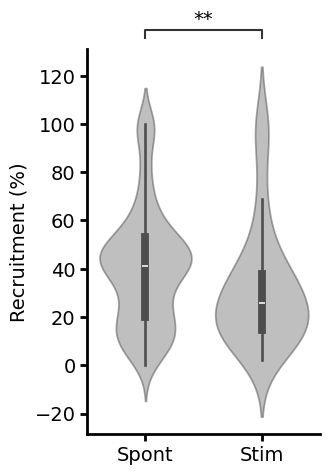

In [12]:
recruitment_df = sz_annots_rs.groupby(['patient']).apply(pt_total_sz_recruitment,total_sz_recruitment)

# Save total recruitment data for R analysis
recruitment_df_total = recruitment_df.copy()
recruitment_df_total.to_csv(ospj(prodatapath,'recruitment_df_total.csv'), index=False)
print(f"Saved total recruitment data: {len(recruitment_df_total)} rows")

fig,ax = plt.subplots(figsize=(3,5))
# ax = sns.pointplot(recruitment_df,x='stim',y='Recruitment',color='black',marker='_',markersize=30,linestyle='none')
sns.violinplot(recruitment_df,x='stim',y='Recruitment',ax=ax,alpha=0.5,color='gray')
sns.despine()

pval = recruitment_stats_summary(recruitment_df)

annotator = Annotator(ax,[(True,False)],data=recruitment_df,x='stim',y='Recruitment')
annotator.configure(test=None,
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.set_pvalues([pval]).annotate()
plt.xticks([0,1],['Spont','Stim'])
plt.xlabel('')
plt.ylabel('Recruitment (%)')
recruitment_df.groupby('stim').apply(recruitment_summary);
fig.savefig(ospj(figpath,"total_recruitment.pdf"),bbox_inches='tight')

In [15]:
recruitment_df.head()

Recruitment   stim  patient
patient                               
CHOP005 0    35.507246  False  CHOP005
        1    50.724638  False  CHOP005
        2    47.826087  False  CHOP005
        3    30.434783  False  CHOP005
        4    16.666667   True  CHOP005

#### Onset channels

Saved onset recruitment data: 441 rows
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Recruitment
No. Observations: 441     Method:             REML       
No. Groups:       30      Scale:              77.8794    
Min. group size:  2       Log-Likelihood:     -1603.2126 
Max. group size:  139     Converged:          Yes        
Mean group size:  14.7                                   
---------------------------------------------------------
                Coef.  Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept        7.253    1.063 6.825 0.000  5.170  9.336
stim[T.True]     5.677    1.496 3.795 0.000  2.745  8.608
Group Var       22.400    0.960                          


Approximate p-value for stim (using t=3.795, df=28): 0.0007252
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 <

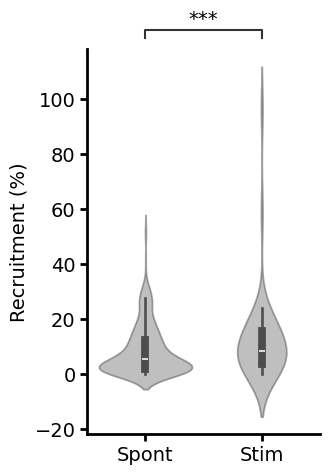

In [13]:
recruitment_df = sz_annots_rs.groupby(['patient']).apply(pt_total_sz_recruitment,total_onset_recruitment)

# Save onset recruitment data for R analysis
recruitment_df_onset = recruitment_df.copy()
recruitment_df_onset.to_csv(ospj(prodatapath,'recruitment_df_onset.csv'), index=False)
print(f"Saved onset recruitment data: {len(recruitment_df_onset)} rows")

fig,ax = plt.subplots(figsize=(3,5))
# ax = sns.pointplot(recruitment_df,x='stim',y='Recruitment',color='black',marker='_',markersize=30,linestyle='none')
sns.violinplot(recruitment_df,x='stim',y='Recruitment',ax=ax,alpha=0.5,color='gray')
sns.despine()

pval = recruitment_stats_summary(recruitment_df)

annotator = Annotator(ax,[(True,False)],data=recruitment_df,x='stim',y='Recruitment')
annotator.configure(test=None,
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.set_pvalues([pval]).annotate()
plt.xticks([0,1],['Spont','Stim'])
plt.xlabel(''
)
plt.ylabel('Recruitment (%)')
recruitment_df.groupby('stim').apply(recruitment_summary);
fig.savefig(ospj(figpath,"onset_recruitment.pdf"),bbox_inches='tight')

#### Spread channels

Saved spread recruitment data: 441 rows
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Recruitment
No. Observations:  441     Method:             REML       
No. Groups:        30      Scale:              369.7211   
Min. group size:   2       Log-Likelihood:     -1955.0334 
Max. group size:   139     Converged:          Yes        
Mean group size:   14.7                                   
----------------------------------------------------------
              Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept     38.340    3.273 11.714 0.000  31.925  44.755
stim[T.True] -17.609    3.303 -5.331 0.000 -24.083 -11.135
Group Var    257.492    4.421                             


Approximate p-value for stim (using t=-5.331, df=28): 1.123e-05
p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      

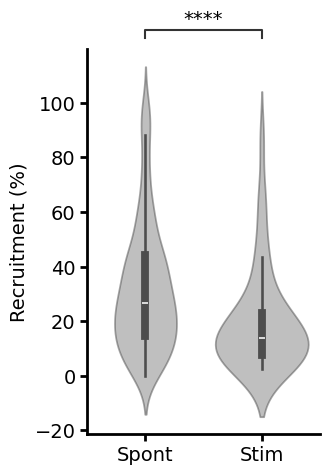

In [14]:
recruitment_df = sz_annots_rs.groupby(['patient']).apply(pt_total_sz_recruitment,total_nonset_recruitment)

# Save spread recruitment data for R analysis
recruitment_df_spread = recruitment_df.copy()
recruitment_df_spread.to_csv(ospj(prodatapath,'recruitment_df_spread.csv'), index=False)
print(f"Saved spread recruitment data: {len(recruitment_df_spread)} rows")

fig,ax = plt.subplots(figsize=(3,5))
# ax = sns.pointplot(recruitment_df,x='stim',y='Recruitment',color='black',marker='_',markersize=30,linestyle='none')
sns.violinplot(recruitment_df,x='stim',y='Recruitment',ax=ax,alpha=0.5,color='gray')
sns.despine()

pval = recruitment_stats_summary(recruitment_df)

annotator = Annotator(ax,[(True,False)],data=recruitment_df,x='stim',y='Recruitment')
annotator.configure(test=None,
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.set_pvalues([pval]).annotate()
plt.xticks([0,1],['Spont','Stim'])
plt.xlabel(''
)
plt.ylabel('Recruitment (%)')
recruitment_df.groupby('stim').apply(recruitment_summary)
fig.savefig(ospj(figpath,"spread_recruitment.pdf"),bbox_inches='tight')

## Seizure spread timing

In [13]:
def analyze_spont_seizure_recruitment(sz_annots, onset='ueo_chs_strict', spread='sz_chs', source = 'all_channels'):
    spread_data = []
    timing_data = []

    for pt, group in sz_annots.groupby("patient"):
        stim_szs = group[group.stim == 1]
        spont_szs = group[group.stim == 0]

        for _, st_sz in stim_szs.iterrows():
            onset_locs = np.unique(np.array(st_sz[onset], dtype=str))
            if onset_locs.ndim == 0:
                onset_locs = np.array([onset_locs])
            if len(onset_locs) == 0:
                if len(st_sz.sz_times) > 0:
                    onset_time = st_sz.sz_times.min()
                    onset_locs = st_sz.sz_chs[st_sz.sz_times <= onset_time + 1]
                else:
                    print(pt,st_sz.approximate_onset)
                    continue
            onset_locs = [o for o in onset_locs if o in st_sz[source]]
            fractions = []
            medians = []
            means = []
            pct25s = []

            for _, sp_sz in spont_szs.iterrows():
                sp_units = np.array(sp_sz[spread], dtype=str)
                sp_times = np.array(sp_sz.sz_times)
                if sp_units.size==0:
                    continue
                # Dictionary of earliest time per unit
                unit_to_time = pd.DataFrame({
                    "unit": sp_units,
                    "time": sp_times
                }).groupby("unit")["time"].min().to_dict()
                fallback_time = np.max(sp_times)

                # Analysis 1: Fraction of stim onset locs found in spontaneous units
                is_recruited = np.isin(onset_locs, sp_units)
                frac_recruited = np.sum(is_recruited) / len(onset_locs)
                fractions.append(frac_recruited)

                # Analysis 2: For each stim onset loc, get min time or fallback
                matched_times = [unit_to_time.get(loc, fallback_time) for loc in onset_locs]
                if matched_times:
                    medians.append(np.median(matched_times))
                    means.append(np.mean(matched_times))
                    pct25s.append(np.percentile(matched_times, 25,method='nearest'))

            # Final aggregation across all spontaneous seizures
            typ_keys = ['Atypical','Typical']
            spread_data.append({
                "patient": pt,
                "typical": typ_keys[int(st_sz.typical)],
                "Fraction": np.percentile(fractions, 75,method='nearest')*100
            })

            if len(medians) > 0:
                timing_data.append({
                    "patient": pt,
                    "typical": typ_keys[int(st_sz.typical)],
                    "onset_median": np.median(medians),
                    "onset_mean": np.median(means),
                    "onset_med_25": np.percentile(medians,25,method='nearest')  # or np.mean(pct25s) depending on preference
                })

    return pd.DataFrame(spread_data), pd.DataFrame(timing_data)

def analyze_spont_seizure_null_recruitment(sz_annots, onset='ueo_chs_strict',spread='sz_chs', source='all_chs', 
                                            n_perm=50, seed=2358):
    spread_data = []
    rng = np.random.default_rng(seed)

    for pt, group in sz_annots.groupby("patient"):
        stim_szs = group[group.stim == 1]
        spont_szs = group[group.stim == 0]

        for _, st_sz in stim_szs.iterrows():
            full_pool = np.array(st_sz[source], dtype=str)
            onset_pool = np.unique(st_sz[onset])
            onset_pool = np.array([o for o in onset_pool if o in full_pool])

            if onset_pool.ndim == 0 or len(onset_pool) == 0:
                if len(st_sz.sz_times) > 0:
                    onset_time = st_sz.sz_times.min()
                    onset_pool = st_sz.sz_chs[st_sz.sz_times <= onset_time + 1]
                else:
                    continue

            for _ in range(n_perm):
                onset_locs = rng.choice(full_pool, size=len(onset_pool), replace=False)

                fractions = []
                latencies_25p = []

                for _, sp_sz in spont_szs.iterrows():
                    sp_units = np.array(sp_sz[spread], dtype=str)
                    sp_times = np.array(sp_sz.sz_times)

                    if sp_units.size == 0:
                        continue

                    unit_to_time = pd.DataFrame({
                        "unit": sp_units,
                        "time": sp_times
                    }).groupby("unit")["time"].min().to_dict()
                    fallback_time = np.max(sp_times)

                    is_recruited = np.isin(onset_locs, sp_units)
                    frac_recruited = np.sum(is_recruited) / len(onset_locs)
                    if np.isnan(frac_recruited):
                        print('check')
                    fractions.append(frac_recruited)

                    matched_times = [unit_to_time.get(loc, fallback_time) for loc in np.unique(onset_locs)]
                    if np.isnan(np.median(matched_times)):
                        print('med check')
                    latencies_25p.append(np.median(matched_times))

                typ_keys = ['Atypical', 'Typical']
                spread_data.append({
                    "patient": pt,
                    "typical": typ_keys[int(st_sz.typical)],
                    "Fraction": np.percentile(fractions, 75,method='nearest') * 100,
                    "Latency": np.percentile(latencies_25p, 25,method='nearest')
                })

    return pd.DataFrame(spread_data)

In [14]:
spread_df,time_df = analyze_spont_seizure_recruitment(sz_annots,onset='ueo_chs_strict',spread='sz_chs',source='all_channels')
null_df = analyze_spont_seizure_null_recruitment(sz_annots, onset='ueo_chs_strict',spread='sz_chs', source='all_channels', 
                                            n_perm=1000, seed=2358)

In [15]:
temp_df = null_df.copy()
temp_df['typical'] = 'All'
null_df_all = pd.concat([temp_df,null_df])
print(spread_df[spread_df.typical=='Typical'].typical.count())
print(spread_df[spread_df.typical=='Atypical'].typical.count())
print(null_df_all[null_df_all.typical=='All'].Fraction.median())
print(null_df_all[null_df_all.typical=='All'].Latency.median())

25
18
56.52173913043478
18.5


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Typical vs. Atypical: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.060e-01 U_stat=1.835e+02


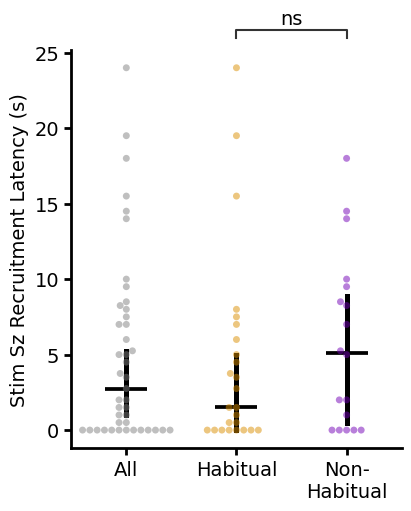

In [19]:
key = 'onset_med_25'
temp_df = time_df.copy()
temp_df['typical'] = 'All'
time_df_all = pd.concat([temp_df,time_df])
fig,ax = plt.subplots(figsize=(4,5),constrained_layout=True)
ax = sns.swarmplot(time_df_all,x='typical',y=key,ax=ax,alpha=0.5,
hue='typical',palette= ['gray','#da8e00','#7300b7',])
ax = sns.pointplot(time_df_all,x='typical',y=key,color='black',marker='_',markersize=30,linestyle='none',estimator='median')
sns.despine()
annotator = Annotator(ax,[("Atypical","Typical")],data=time_df_all,x='typical',y=key)
annotator.configure(test='Mann-Whitney',
        comparisons_correction = 'Benjamini-Hochberg',
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]],)
annotator.apply_test().annotate()
plt.xticks([0,1,2],['All','Habitual','Non-\nHabitual'])
plt.xlabel('')
plt.ylabel('Stim Sz Recruitment Latency (s)')
symbols = ['x','*','x']
# for i,col in enumerate(['All','Typical','Atypical']):
#     plt.text(i,26,symbols[i],fontsize=14,ha='center',color='red')
#     med_lat = null_df_all[null_df_all.typical==col].Latency.median()
#     upper_lat = np.percentile(null_df_all[null_df_all.typical==col].Latency,10)
#     q, = plt.plot([i-0.2,i+0.2],[med_lat]*2,linestyle='-',c='red')
#     p, = plt.plot([i-0.2,i+0.2],[upper_lat]*2,linestyle='--',c='red')
# q.set_label('Null Latency (50%)')
# p.set_label('Null Latency (90%)')
# plt.legend()
# fig.tight_layout()
fig.savefig(ospj(figpath,'spont-stim_ueo_median_region_latency.pdf'))

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Typical vs. Atypical: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.934e-01 U_stat=2.025e+02


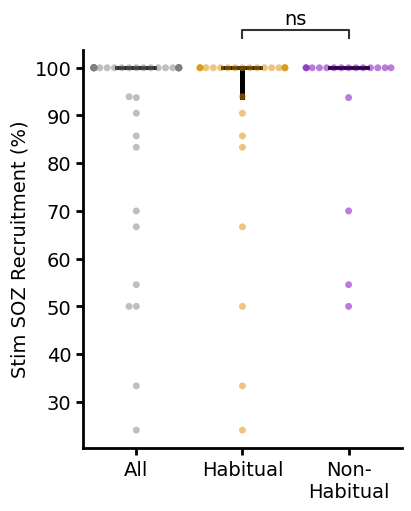

In [20]:
key = 'Fraction'
temp_df = spread_df.copy()
temp_df['typical'] = 'All'
spread_df_all = pd.concat([temp_df,spread_df])
fig,ax = plt.subplots(figsize=(4,5),constrained_layout=True)
ax = sns.swarmplot(spread_df_all,x='typical',y=key,ax=ax,alpha=0.5,
hue='typical',palette= ['gray','#da8e00','#7300b7',])
ax = sns.pointplot(spread_df_all,x='typical',y=key,color='black',marker='_',markersize=30,linestyle='none',estimator='median')
sns.despine()
annotator = Annotator(ax,[("Atypical","Typical")],data=spread_df_all,x='typical',y=key)
annotator.configure(test='Mann-Whitney',
        comparisons_correction = 'Benjamini-Hochberg',
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]],)
annotator.apply_test().annotate()
plt.xticks([0,1,2],['All','Habitual','Non-\nHabitual'])
plt.xlabel('')
plt.ylabel('Stim SOZ Recruitment (%)')
symbols = ['*','*','x']
# for i,col in enumerate(['All','Typical','Atypical']):
#     plt.text(i,105,'ns',fontsize=14,ha='center',color='red')
#     med_lat = null_df_all[null_df_all.typical=='All'].Fraction.median()
#     upper_lat = np.percentile(null_df_all[null_df_all.typical=='All'].Fraction,90)
#     q, = plt.plot([i-0.2,i+0.2],[med_lat]*2,linestyle='-',c='red')
#     p, = plt.plot([i-0.2,i+0.2],[upper_lat]*2,linestyle='--',c='red')
# q.set_label('Null Recruitment (50%)')
# p.set_label('Null Recruitment (90%)')
# plt.legend()
# fig.tight_layout()
fig.savefig(ospj(figpath,'spont-stim_ueo_median_region_spread.pdf'))

In [18]:
wil_ps = []
lat_ps = []
for col in ['All','Typical','Atypical']:
    med_frac = spread_df_all[spread_df_all.typical == col].Fraction.median()
    frac_25 = np.percentile(spread_df_all[spread_df_all.typical==col].Fraction,25,method='nearest')
    frac_75 = np.percentile(spread_df_all[spread_df_all.typical==col].Fraction,75,method='nearest')
    med_lat = time_df_all[time_df_all.typical==col].onset_med_25.median()
    stat,p = sc.stats.wilcoxon(time_df_all[time_df_all.typical==col].onset_med_25-10)
    print(col, p, stat)
    wil_ps.append(p)
    lat_25 = np.percentile(time_df_all[time_df_all.typical==col].onset_med_25,25,method='nearest')
    lat_75 = np.percentile(time_df_all[time_df_all.typical==col].onset_med_25,75,method='nearest')
    key = 'All'
    frac_pval = (np.sum(null_df_all[null_df_all.typical==key].Fraction >= med_frac)+1)/(len(null_df_all[null_df_all.typical==key])+1)
    lat_pval = (np.sum(null_df_all[null_df_all.typical==key].Latency <= med_lat)+1)/(len(null_df_all[null_df_all.typical==key])+1)
    lat_ps.append(lat_pval)
    print(f"{col} Latency - {med_lat} ({lat_25},{lat_75}) pval = {lat_pval}")
    print(f"{col} Fraction - {med_frac} ({frac_25},{frac_75}) pval = {frac_pval}")
print(multipletests(wil_ps))
print(multipletests(lat_ps))

# Save dataframes for R analysis
time_df_all.to_csv(ospj(prodatapath,'time_df_all.csv'), index=False)
spread_df_all.to_csv(ospj(prodatapath,'spread_df_all.csv'), index=False)
null_df_all.to_csv(ospj(prodatapath,'null_df_all.csv'), index=False)
print(f"Saved dataframes for R analysis:")
print(f"- time_df_all: {len(time_df_all)} rows")
print(f"- spread_df_all: {len(spread_df_all)} rows") 
print(f"- null_df_all: {len(null_df_all)} rows")

All 3.545539433961957e-05 122.0
All Latency - 2.75 (0.0,8.0) pval = 0.04560359061417176
All Fraction - 100.0 (93.75,100.0) pval = 0.23434338736308458
Typical 0.0010271072387695312 46.5
Typical Latency - 1.5 (0.0,6.0) pval = 0.03330155112671798
Typical Fraction - 100.0 (90.47619047619048,100.0) pval = 0.23434338736308458
Atypical 0.008385491638745088 21.0
Atypical Latency - 5.125 (0.0,9.5) pval = 0.07176577288900259
Atypical Fraction - 100.0 (100.0,100.0) pval = 0.23434338736308458
(array([ True,  True,  True]), array([0.00010636, 0.00205316, 0.00838549]), 0.016952427508441503, 0.016666666666666666)
(array([False, False, False]), array([0.0966146, 0.0966146, 0.0966146]), 0.016952427508441503, 0.016666666666666666)
Saved dataframes for R analysis:
- time_df_all: 86 rows
- spread_df_all: 86 rows
- null_df_all: 86000 rows


## Predicting Electrographic Similarity

### Calculating seizure level metadata

#### Seizure similarity

In [13]:
def model_seizure_similarity(annots,first_annot = 'ueo_consensus', second_annot = 'ueo_consensus',paired=True):
    annot_list = ["kappa","F1","MCC","patient","IEEGname","approximate_onset","stim_sz_length","stim_sz_spread"]
    annot_dict = {key:[] for key in annot_list}
    skip_pt = []
    for pt,group in annots.groupby("patient"):
        if (sum(group.stim == 0) < 2) and paired:
            skip_pt.append(pt)
            continue
        elif len(group) < 2:
            skip_pt.append(pt)
            continue
        # Iterate through each seizure
        for i in range(len(group)):
            group.reset_index(drop=True,inplace=True)
            if group.loc[i,'stim'] == 1:
                ch_mask = group.loc[i,first_annot].reshape(-1,)
                for j in range(len(group)):
                    if (group.loc[i,'stim'] == 1)  and (group.loc[j,'stim'] == 1): # skip both stim
                        continue
                    ch_mask2 = group.loc[j,second_annot].reshape(-1,)
                    annot_dict["kappa"].append(cohen_kappa_score(ch_mask,ch_mask2))
                    annot_dict["F1"].append(f1_score(ch_mask,ch_mask2))
                    annot_dict["MCC"].append(matthews_corrcoef(ch_mask,ch_mask2))
                    annot_dict["patient"].append(pt)
                    annot_dict["IEEGname"].append(group.loc[i,'iEEG_ID'])
                    annot_dict["approximate_onset"].append(group.loc[i,'approximate_onset'])
                    annot_dict["stim_sz_length"].append(group.loc[i,'offset']-group.loc[i,'approximate_onset'])
                    annot_dict['stim_sz_spread'].append(len(group.loc[i,'sz_chs'])/len(group.loc[i,'all_channels']))
                    
    annot_df = pd.DataFrame(annot_dict)
    print(f"Skipped {skip_pt} due to insufficient spontaneous seizures")
    return annot_df

In [14]:
model_df = model_seizure_similarity(sz_annots_rs,first_annot='ueo_rs_strict_mask',second_annot='ueo_rs_strict_mask',paired = False)
model_df = model_df.rename(columns={'IEEGname':'iEEG_ID'})
model_df = model_df.sort_values('approximate_onset')
print(model_df.patient.nunique())

Skipped [] due to insufficient spontaneous seizures
30


In [15]:
model_df[model_df.patient == 'CHOP037']

,kappa,F1,MCC,patient,iEEG_ID,approximate_onset,stim_sz_length,stim_sz_spread
137,0.272727,0.333333,0.397360,CHOP037,CHOPCCEP_037,14410.98,60.85,0.14375
138,0.067797,0.153846,0.187317,CHOP037,CHOPCCEP_037,14410.98,60.85,0.14375
139,0.067797,0.153846,0.187317,CHOP037,CHOPCCEP_037,14410.98,60.85,0.14375
140,-0.090909,0.000000,-0.132453,CHOP037,CHOPCCEP_037,15155.13,97.87,0.08125
141,0.067797,0.153846,0.187317,CHOP037,CHOPCCEP_037,15155.13,97.87,0.08125
142,0.067797,0.153846,0.187317,CHOP037,CHOPCCEP_037,15155.13,97.87,0.08125


#### Merging with metadata

In [16]:
model_df_wtypical = pd.merge_asof(model_df,
                                    seizures_df[['approximate_onset','patient',"iEEG_ID","to_annotate","typical"]],
                                    on='approximate_onset',by=['patient','iEEG_ID'],
                                    tolerance = 240,
                                    direction='nearest')

In [17]:
model_df_wtypical.typical = model_df_wtypical.typical == 1

In [18]:
metadata_table = pd.read_csv(ospj(metapath,'stim_seizure_information - metadata-4.csv')).loc[:,["record_id","hupsubjno",
                                                                                            "Laterality","unifocal",
                                                                                            "localization","duration",
                                                                                            "outcome","lesional","age_at_onset"]]
metadata_table['stim_sz'] = metadata_table['hupsubjno'].apply(int).isin(patient_table.ptID.apply(lambda x: int(x[3:])))
metadata_table['mtle'] = metadata_table.localization.apply(lambda x: 'MTLE' in x if not isinstance(x,float) else False)
# metadata_table['mtle'] = metadata_table.localization == 'MTLE'
metadata_table["unifocal"] = metadata_table.unifocal == 1
metadata_table["lesional"] = metadata_table.lesional > 0
metadata_table["ptID"] = "HUP" + metadata_table["hupsubjno"].astype(str)
# metadata_table.loc[metadata_table.unifocal == 0,'mtle'] = pd.NA

In [19]:
kiddata_table = pd.read_csv(ospj(metapath,'CHOP_metadata.csv'))
kiddata_table['duration'] = kiddata_table['duration of epilepsy prior to stim (y)']
kiddata_table['age_at_onset'] = kiddata_table['age at epilepsy onset']
kiddata_table['unifocal'] = kiddata_table.unifocal == 1
kiddata_table['mtle'] = kiddata_table.mtle == 1
kiddata_table['lesional'] = kiddata_table.lesional == 1
# kiddata_table.head()

In [20]:
all_metadata_table = pd.concat((metadata_table,kiddata_table))[['ptID','unifocal','mtle','outcome','duration','age_at_onset','lesional','stim_sz']]
all_metadata_table['adult'] = all_metadata_table.ptID.apply(lambda x: 'HUP' in x)
all_metadata_table['age'] = all_metadata_table['age_at_onset'] + all_metadata_table['duration']
all_metadata_table.head()

,ptID,unifocal,mtle,outcome,duration,age_at_onset,lesional,stim_sz,adult,age
0,HUP211,False,True,NaN,11.3,12.0,True,0,True,23.3
1,HUP212,False,False,NaN,13.9,42.0,True,0,True,55.9
2,HUP213,True,True,NaN,19.1,2.0,True,0,True,21.1
3,HUP214,False,True,NaN,8.6,32.0,False,0,True,40.6
4,HUP216,True,False,1.0,21.1,3.0,False,0,True,24.1


In [21]:
combiner=COMBINER
def percentile(x,combiner=combiner):
    return np.percentile(x,combiner,method='nearest')
model_df_grouped = model_df_wtypical.groupby('approximate_onset')
model_df_left = model_df_grouped[[l for l in model_df_wtypical.columns if l not in ['MCC','F1','kappa']]].max()
model_df_left['MCC'] = model_df_grouped['MCC'].apply(percentile)
model_df_left['F1'] = model_df_grouped['F1'].apply(percentile)
model_df_left['kappa'] = model_df_grouped['kappa'].apply(percentile)


In [22]:
# Join the two tables and make linear model!
lm_df_left = pd.merge(model_df_left,all_metadata_table[['ptID','mtle','outcome','unifocal','lesional','adult','duration','age_at_onset','age']],left_on='patient',right_on='ptID',how='inner').drop('ptID',axis=1)
lm_df_left.dropna(axis=0,subset=['MCC','F1','mtle','unifocal','typical','lesional'],how='any',inplace=True)
lm_df_left.to_csv(ospj(prodatapath,'modeling_df.csv'),index=False)

In [23]:
lm_df_left.head()

,patient,iEEG_ID,approximate_onset,stim_sz_length,stim_sz_spread,to_annotate,typical,MCC,F1,kappa,mtle,outcome,unifocal,lesional,adult,duration,age_at_onset,age
0,HUP229,HUP229_phaseII,1109.40,67.51,0.404762,1.0,True,0.440386,0.571429,0.432432,True,0.0,True,True,True,32.900000,8.0,40.900000
1,CHOP010,CHOPCCEP_010,2230.26,37.52,0.378947,1.0,False,0.000000,0.000000,0.000000,True,0.0,False,True,False,2.912389,13.0,15.912389
2,CHOP010,CHOPCCEP_010,3771.99,33.69,0.452632,NaN,True,0.254824,0.307692,0.121951,True,0.0,False,True,False,2.912389,13.0,15.912389
3,CHOP035,CHOPCCEP_035,2872.35,26.71,0.153409,1.0,True,0.516398,0.571429,0.421053,True,NaN,True,True,False,2.360712,15.0,17.360712
4,CHOP035,CHOPCCEP_035,6553.27,18.56,0.193182,1.0,True,0.690066,0.800000,0.645161,True,NaN,True,True,False,2.360712,15.0,17.360712


### Univariate Plotting

In [24]:
def univariate_summary(group):
    x = group['MCC']
    med = np.round(x.median(),2)
    lower = np.round(np.nanpercentile(x,25,method='nearest'),2)
    upper = np.round(np.nanpercentile(x,75,method='nearest'),2)
    print(f"N = {len(x)} Med {med} [{lower}, {upper}]")
    return None

In [25]:
# Mixed-effects model function for univariate analysis
def univariate_mixed_effects_test(data, variable, outcome='MCC', patient_col='patient'):
    """
    Perform mixed-effects model test for a binary predictor with random intercept for patient
    """
    try:
        # Fit mixed-effects model: MCC ~ variable + (1|patient)
        formula = f'{outcome} ~ {variable}'
        model = MixedLM.from_formula(formula, data=data, groups=data[patient_col])
        fit = model.fit()
        # Extract coefficient for the variable (skip intercept)
        param_names = list(fit.params.index)
        var_param = [p for p in param_names if variable in p and p != 'Intercept'][0]
        
        # Extract statistics
        z_val = fit.tvalues[var_param]
        ci_low, ci_high = fit.conf_int().loc[var_param]
        
        # Kenward-Roger approximation for degrees of freedom
        n_obs = len(data)
        n_groups = data['patient'].nunique()
        n_fixed_params = len(fit.params)
        
        # Conservative KR approximation: N - n_groups - n_fixed_params
        kr_ddf = n_obs - n_groups - n_fixed_params
        
        # Convert z-statistic to t-statistic and calculate KR-corrected p-value
        t_stat = z_val  # For large samples, z ≈ t
        kr_pval = 2 * (1 - stats.t.cdf(abs(t_stat), kr_ddf))
        # Extract p-value for the variable of interest
        # Handle different parameter naming conventions
        variable_effect = None
        for param in fit.params.index:
            if variable in param and param != 'Intercept':
                variable_effect = param
                break
        
        if variable_effect is None:
            print(f"Warning: Could not find parameter for {variable}")
            return {'pvalue': np.nan, 'coefficient': np.nan, 'model_fit': None}
        
        pvalue = fit.pvalues[variable_effect]
        coef = fit.params[variable_effect]
        
        return {
            'pvalue': pvalue,
            'kr_pval': kr_pval,
            'kr_dof': kr_ddf,
            'coefficient': coef,
            'ci': (ci_low, ci_high),
            'model_fit': fit,
            'parameter_name': variable_effect
        }
    except Exception as e:
        print(f"Error fitting model for {variable}: {str(e)}")
        return {'pvalue': np.nan, 'coefficient': np.nan, 'model_fit': None}



=== MTLE MIXED-EFFECTS ANALYSIS ===
N = 15 Med 0.09 [0.0, 0.4]
N = 28 Med 0.42 [0.0, 0.69]


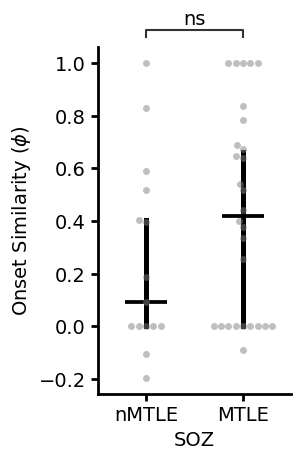


=== ADULT MIXED-EFFECTS ANALYSIS ===
N = 20 Med 0.4 [0.0, 0.59]
N = 23 Med 0.09 [0.0, 0.65]


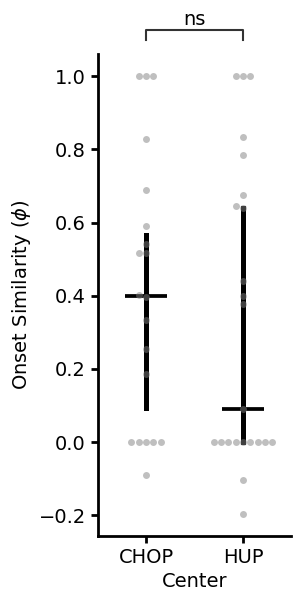


=== TYPICAL MIXED-EFFECTS ANALYSIS ===
N = 18 Med 0.0 [0.0, 0.38]
N = 25 Med 0.54 [0.25, 0.83]


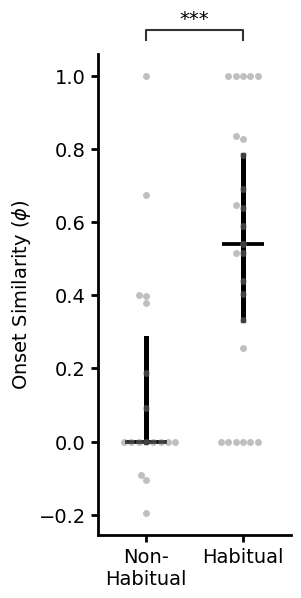

In [28]:
for col in ['mtle','adult','typical']:#,'lesional','stim_sz_spread','stim_sz_length','duration']:
    if lm_df_left[col].nunique() <= 3:
        print(f"\n=== {col.upper()} MIXED-EFFECTS ANALYSIS ===")
        lm_df_left.groupby(col).apply(univariate_summary)
        
        # Perform mixed-effects test instead of Mann-Whitney
        mixed_results = univariate_mixed_effects_test(lm_df_left, col)
        # print(f"Mixed-effects model parameter: {mixed_results.get('parameter_name', 'N/A')}")
        # print(f"Mixed-effects model p-value: {mixed_results['pvalue']:.6f}")
        # print(f"Coefficient: {mixed_results['coefficient']:.4f}")
        
        # Print model summary if available
        # if mixed_results['model_fit'] is not None:
            # print("\nFull model summary:")
            # # print(mixed_results['model_fit'].summary())
            # print(f"KR Adj: DOF({mixed_results['kr_dof']}, p = {mixed_results['kr_pval']})")
        
        _,ax = plt.subplots(figsize=(2.5,6.25))
        sns.swarmplot(lm_df_left,x=col,y='MCC',color='gray',alpha=0.5,ax=ax)
        sns.pointplot(lm_df_left,x=col,y='MCC',marker='_',linestyles='none',markersize=30,color='black',ax=ax,estimator='median')
        plt.ylabel('Onset Similarity ($\phi$)')
        sns.despine()

        if col == 'typical':
            plt.xticks([0,1],['Non-\nHabitual','Habitual'])
            plt.xlabel('')
            # plt.ylim([-.1,1.2])
            # plt.title('Seizure-Level Seizure Similarity')
            annotator = Annotator(ax,[(False,True)],data=lm_df_left,x=col,y='MCC')
            (annotator
            .configure(test=None,
            loc='outside',
            text_format='star',
            fontsize=14,
            pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                            [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]],
            verbose=False)
            .set_pvalues([0.001]) # From R mixed-effects model
            .annotate()
            )
            plt.savefig(ospj(figpath,'stim_univariate_typical.pdf'),bbox_inches='tight')
        
        if col == 'mtle':
            plt.close()
            _,ax = plt.subplots(figsize=(2.5,4.5))
            sns.swarmplot(lm_df_left,x=col,y='MCC',color='gray',alpha=0.5,ax=ax)
            sns.pointplot(lm_df_left,x=col,y='MCC',marker='_',linestyles='none',markersize=30,color='black',ax=ax,estimator='median')
            plt.ylabel('Onset Similarity ($\phi$)')
            sns.despine()
            plt.xticks([0,1],['nMTLE','MTLE'],
            # rotation=0
            )
            plt.xlabel('SOZ')
            # plt.ylim([-.1,1.2])
            # plt.title('Seizure-Level Seizure Similarity')
            annotator = Annotator(ax,[(False,True)],data=lm_df_left,x=col,y='MCC')
            (annotator
            .configure(test=None,
            loc='outside',
            text_format='star',
            fontsize=14,
            pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                            [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]],
            verbose=False)
            .set_pvalues([0.14]) # From R mixed-effects model
            .annotate()
            )
            plt.savefig(ospj(figpath,'stim_univariate_mtle.pdf'),bbox_inches='tight')
        if col == 'adult':
            plt.xticks([0,1],['CHOP','HUP'],rotation=0)
            plt.xlabel('Center')
            # plt.ylim([-.1,1.2])
            # plt.title('Seizure-Level Seizure Similarity')
            annotator = Annotator(ax,[(False,True)],data=lm_df_left,x=col,y='MCC')
            (annotator
            .configure(test=None,
            loc='outside',
            text_format='star',
            fontsize=14,
            pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                            [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]],   
            verbose=False)
            .set_pvalues([mixed_results['kr_pval']])
            .annotate()
            )
    plt.show()


### Semiology

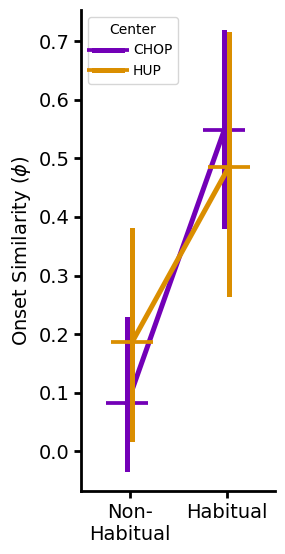

In [34]:
plot_df = lm_df_left.copy()
plot_df['adult'] = plot_df.adult.map({True:'HUP',False:'CHOP'})
_,ax = plt.subplots(figsize=(2.5,6.25))
sns.pointplot(
    data = plot_df,
    x='typical',
    y='MCC',
    hue='adult',
    marker='_',markersize=30,
    palette=['#7300b7','#da8e00'],
    # order = ['Atypical','Typical'],
    ax=ax,
    dodge=True,
    )
plt.ylabel('Onset Similarity ($\phi$)')
sns.despine()
plt.xticks([0,1],['Non-\nHabitual','Habitual'])
plt.legend(title='Center')
plt.xlabel('')
plt.savefig(ospj(figpath,'stim_univariate_typical_by_center.pdf'),bbox_inches='tight')

### Localization

#### Center effects

In [42]:
center_mdl = smf.ols(formula='MCC ~ adult*mtle',data=lm_df_left).fit()
print(center_mdl.summary())

                            OLS Regression Results                            
Dep. Variable:                    MCC   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     3.955
Date:                Mon, 14 Jul 2025   Prob (F-statistic):             0.0148
Time:                        10:50:34   Log-Likelihood:                -13.841
No. Observations:                  43   AIC:                             35.68
Df Residuals:                      39   BIC:                             42.73
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

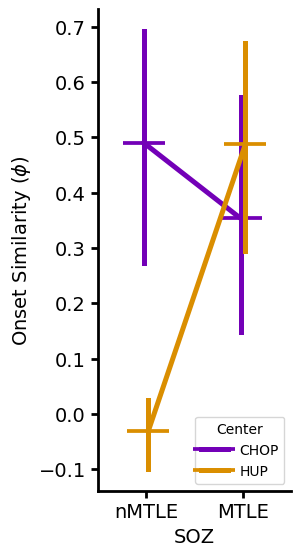

In [33]:
plot_df = lm_df_left.copy()
plot_df['adult'] = plot_df.adult.map({True:'HUP',False:'CHOP'})
_,ax = plt.subplots(figsize=(2.5,6.25))
sns.pointplot(
    data = plot_df,
    x='mtle',
    y='MCC',
    hue='adult',
    marker='_',markersize=30,
    palette=['#7300b7','#da8e00'],
    ax=ax,
    dodge=True,
    )
plt.ylabel('Onset Similarity ($\phi$)')
sns.despine()
plt.xticks([0,1],['nMTLE','MTLE'])
plt.xlabel('SOZ')
plt.legend(title='Center')
plt.savefig(ospj(figpath,'stim_univariate_mtle_by_age.pdf'),bbox_inches='tight')
print()

#### Age effects

In [40]:
onset_split = lm_df_left.age_at_onset.median(); print(onset_split)
dur_split = lm_df_left.duration.median()
age_split = lm_df_left.age.median()
lm_df_left['onset_age'] = (lm_df_left.age_at_onset>onset_split).map({False:f'$\leq${int(onset_split)}',True:f'>{int(onset_split)}'})
lm_df_left['epilepsy_duration'] = (lm_df_left.duration>dur_split).map({False:f'$\leq${int(dur_split)}',True:f'>{int(dur_split)}'})
lm_df_left['implant_age'] = (lm_df_left.age>age_split).map({False:f'$\leq${int(age_split)}',True:f'>{int(age_split)}'})

14.0


In [41]:
age_mdl = smf.ols(formula='MCC ~mtle*implant_age',data=lm_df_left).fit()
dur_mdl = smf.ols(formula='MCC ~ mtle*epilepsy_duration',data=lm_df_left).fit()
onset_mdl = smf.ols(formula='MCC ~ mtle*onset_age',data=lm_df_left).fit()
print(age_mdl.rsquared, age_mdl.f_pvalue)
print(dur_mdl.rsquared,dur_mdl.f_pvalue)
print(onset_mdl.rsquared,onset_mdl.f_pvalue)
print(onset_mdl.summary())

0.1856781266153854 0.04378347254377619
0.11489074422351675 0.18550297968083673
0.24840938783650568 0.01032877186044533
                            OLS Regression Results                            
Dep. Variable:                    MCC   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     4.297
Date:                Fri, 18 Jul 2025   Prob (F-statistic):             0.0103
Time:                        15:14:56   Log-Likelihood:                -13.411
No. Observations:                  43   AIC:                             34.82
Df Residuals:                      39   BIC:                             41.87
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      

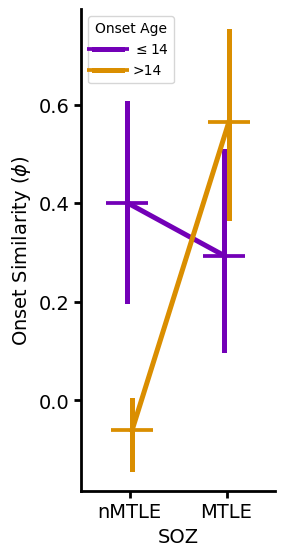

In [48]:
split = plot_df.age_at_onset.median()
plot_df['onset_age'] = (lm_df_left.age_at_onset>split).map({False:f'$\leq${int(split)}',True:f'>{int(split)}'})
_,ax = plt.subplots(figsize=(2.5,6.25))
sns.pointplot(
    data = plot_df,
    x='mtle',
    y='MCC',
    hue='onset_age',
    marker='_',markersize=30,
    palette=['#7300b7','#da8e00'],
    ax=ax,
    dodge=True,
    )
plt.ylabel('Onset Similarity ($\phi$)')
sns.despine()
plt.xticks([0,1],['nMTLE','MTLE'])
plt.xlabel('SOZ')
plt.legend(title='Onset Age')
plt.savefig(ospj(figpath,'stim_univariate_mtle_by_age.pdf'),bbox_inches='tight')